In [1]:
!pip install gdown pandas numpy scipy matplotlib

In [2]:
import gdown
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import os
from datetime import datetime

In [3]:
gid_map = {

    'optimality': '36197349'
}

sheet_id = "1e_lKct9ovnYByYkGpFCKrMpKQs5TQdKhTld9tDU1JcQ"

In [4]:
def get_pandas_from_gid(gid_name):
    gid = gid_map[gid_name]

    # Construct export URL
    url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

    # Set desired output filename
    output = f"{gid_name}.csv"

    # Download CSV using gdown
    gdown.download(url, output, quiet=False)
    original_df = pd.read_csv(output)
    return original_df

In [5]:
def calculate_grouped_stats_and_ci(df: pd.DataFrame,
                                   grouping_columns: list,
                                   value_columns: list,
                                   confidence_level: float = 0.95) -> pd.DataFrame:
    """
    Groups a DataFrame by specified columns, calculates mean, count, standard deviation,
    and the confidence interval (using t-distribution) for multiple given value columns.

    Args:
        df (pd.DataFrame): The input Pandas DataFrame.
        grouping_columns (list): A list of column names to group the DataFrame by.
        value_columns (list): A list of column names for which to calculate the mean,
                              count, standard deviation, and confidence interval.
        confidence_level (float, optional): The desired confidence level (e.g., 0.95 for 95%).
                                            Defaults to 0.95.

    Returns:
        pd.DataFrame: A DataFrame containing the grouped results with 'Average', 'Count',
                      'Std_Dev', 'CI_Lower', and 'CI_Upper' columns for each value column.
    """

    # Check if all value_columns are numeric
    for col in value_columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            raise TypeError(f"The '{col}' in value_columns must be a numeric column.")

    # Create an aggregation dictionary for multiple value columns
    agg_dict = {col: ['mean', 'count', 'std'] for col in value_columns}

    # Group by the specified columns and aggregate
    grouped_df = df.groupby(grouping_columns).agg(agg_dict).reset_index()

    # Flatten MultiIndex columns and rename for clarity
    new_columns = []
    for col_pair in grouped_df.columns:
        if col_pair[1]: # If it's a multi-level column (e.g., ('Value', 'mean'))
            new_columns.append(f"{col_pair[0]}_{col_pair[1]}")
        else: # If it's a grouping column
            new_columns.append(col_pair[0])
    grouped_df.columns = new_columns

    # Rename suffixes for consistency
    rename_map = {}
    for col in value_columns:
        rename_map[f'{col}_mean'] = f'{col}_Average'
        rename_map[f'{col}_count'] = f'{col}_Count'
        rename_map[f'{col}_std'] = f'{col}_Std_Dev'
    grouped_df.rename(columns=rename_map, inplace=True)

    # Function to calculate confidence interval for a single row and a specific value column
    def calculate_ci_for_column_in_row(row, col_prefix, conf_level):
        avg = row.get(f'{col_prefix}_Average')
        count = row.get(f'{col_prefix}_Count')
        std_dev = row.get(f'{col_prefix}_Std_Dev')

        # Check for NaN values or insufficient data
        if pd.isna(avg) or pd.isna(count) or pd.isna(std_dev) or count < 2:
            return np.nan, np.nan

        # Degrees of freedom for t-distribution
        df_t = count - 1

        # Calculate standard error of the mean
        sem = std_dev / np.sqrt(count)

        # Calculate confidence interval
        lower, upper = stats.t.interval(conf_level, df_t, loc=avg, scale=sem)
        return lower, upper

    # Apply the confidence interval calculation for each value column
    for col in value_columns:
        grouped_df[[f'{col}_CI_Lower', f'{col}_CI_Upper']] = grouped_df.apply(
            lambda row: calculate_ci_for_column_in_row(row, col, confidence_level),
            axis=1,
            result_type='expand'
        )

    return grouped_df

In [6]:
optimality_df = get_pandas_from_gid('optimality')
optimality_df.loc[optimality_df['objective_function'] == 'triangledensestsubgraph', 'cost_best_solution'] = optimality_df.loc[optimality_df['objective_function'] == 'triangledensestsubgraph', 'cost_best_solution'] / 3
optimality_df = optimality_df.drop(optimality_df[optimality_df['metaheuristic'] == 'ts2'].index)
optimality_df

/home/diogoocv/IdeaProjects/fractal/venv/lib/python3.12/site-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=None
  warnings.warn(
Downloading...
From: https://docs.google.com/spreadsheets/d/1e_lKct9ovnYByYkGpFCKrMpKQs5TQdKhTld9tDU1JcQ/export?format=csv&gid=36197349
To: /home/diogoocv/IdeaProjects/fractal/plots/CCPE_Plots/optimality.csv
7.11MB [00:00, 11.3MB/s]


,graph_name,metaheuristic,initial_vertices,num_initial_solutions,timeout_ms,objective_function,num_threads,repetition,total_time_ms,time_to_best_solution_ms,effective_runs,cost_best_solution,vertices_best_solution,edges_best_solution,best_solution
0,dblp,vns,10,100,3000,triangledensestsubgraph,32,2,9268,0,90,210.000000,37,666,"vsub(nvertices=37,nedges=666,vertices={2294140..."
1,dblp,ts1,10,100,2000,triangledensestsubgraph,32,3,6415,0,90,194.475000,40,675,26/01/31 11:14:26 SubgraphOptimizationApp$ Ela...
2,dblp,vns,10,100,1000,triangledensestsubgraph,32,1,3345,0,90,167.697674,43,659,"vsub(nvertices=43,nedges=659,vertices={2357705..."
4,dblp,vns,10,100,1000,triangledensestsubgraph,32,4,3342,0,90,156.100000,50,699,"vsub(nvertices=50,nedges=699,vertices={2388871..."
6,youtube,ils,10,100,1000,triangledensestsubgraph,32,1,3411,0,96,58.375000,32,345,26/02/23 02:52:13 SubgraphOptimizationApp$ Ela...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4854,patents,ils,10,10000,3000,densesubgraph,32,5,923354,891000,9824,39.957265,117,4675,26/02/22 10:49:27 SubgraphOptimizationApp$ Ela...
4855,patents,ils,10,10000,3000,densesubgraph,32,1,923294,891000,9824,39.871795,117,4665,26/02/22 09:45:48 SubgraphOptimizationApp$ Ela...
4856,patents,ils,10,10000,3000,densesubgraph,32,4,923375,891000,9824,39.470588,119,4697,26/02/22 10:33:33 SubgraphOptimizationApp$ Ela...
4857,patents,ils,10,10000,3000,conductance,32,2,925136,895000,9824,0.865574,312,1848,26/02/22 08:42:36 SubgraphOptimizationApp$ Ela...


In [7]:
grouping_columns = ["graph_name", "metaheuristic", "objective_function", "initial_vertices", "num_initial_solutions", "num_threads"]
value_column = ["cost_best_solution", "total_time_ms"]
grouped_df = calculate_grouped_stats_and_ci(optimality_df, grouping_columns, value_column)
grouped_df

/home/diogoocv/IdeaProjects/fractal/venv/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2334: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/diogoocv/IdeaProjects/fractal/venv/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2335: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


,graph_name,metaheuristic,objective_function,initial_vertices,num_initial_solutions,num_threads,cost_best_solution_Average,cost_best_solution_Count,cost_best_solution_Std_Dev,total_time_ms_Average,total_time_ms_Count,total_time_ms_Std_Dev,cost_best_solution_CI_Lower,cost_best_solution_CI_Upper,total_time_ms_CI_Lower,total_time_ms_CI_Upper
0,amazon,ils,conductance,10,100,32,0.984160,15,0.001765,6355.200000,15,2546.399200,0.983182,0.985137,4945.051126,7765.348874
1,amazon,ils,conductance,10,1000,32,0.993333,15,0.000000,54614.000000,15,22870.832498,NaN,NaN,41948.555122,67279.444878
2,amazon,ils,conductance,10,10000,32,0.995675,15,0.000556,544500.666667,15,229268.395981,0.995367,0.995983,417536.060908,671465.272425
3,amazon,ils,degreeentropy,10,100,32,3.862777,15,0.046390,6325.266667,15,2543.122250,3.837087,3.888467,4916.932506,7733.600827
4,amazon,ils,degreeentropy,10,1000,32,3.934650,15,0.019841,54556.066667,15,22838.290083,3.923662,3.945638,41908.643178,67203.490156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,youtube,vns,labelentropy,10,1000,32,6.743557,15,0.005172,63014.466667,15,26228.191487,6.740692,6.746421,48489.778352,77539.154981
239,youtube,vns,labelentropy,10,10000,32,6.750161,15,0.004601,625638.066667,15,262941.949789,6.747613,6.752709,480025.668371,771250.464963
240,youtube,vns,triangledensestsubgraph,10,100,32,62.945631,15,3.052086,6344.000000,15,2553.109673,61.255442,64.635820,4930.134990,7757.865010
241,youtube,vns,triangledensestsubgraph,10,1000,32,98.016678,15,4.595277,62825.400000,15,26236.646385,95.471898,100.561458,48296.029519,77354.770481


In [81]:
def plot_average_by_group_and_metaheuristic(
        df: pd.DataFrame,
        grouping_columns: list,
        num_initial_solutions: int,
        baseline_scores: dict,
        obj_function: str,
        log_scale: bool,
        figsize: tuple[int, int] = (8, 6)):

    """
    Generates a Matplotlib bar plot showing 'Average' performance with confidence intervals
    as error bars. The x-axis represents combined experimental groups, and 'metaheuristic'
    is used for the legend (differentiating bars within each group).

    Args:
        df (pd.DataFrame): The input DataFrame containing experimental results.
                           Expected columns: 'graph_name', 'metaheuristic',  'objective_function',
                           'initial_vertices', 'timeout_ms', 'num_threads',
                           'num_initial_solutions', 'Average', 'CI_Lower', 'CI_Upper'.
        grouping_columns (list): A list of column names that define the unique
                                 experimental groups for the X-axis.
    """

    axis_fontsize = 30
    axis_title_fontsize = 30
    title_fontsize = 26
    legend_fontsize = 24

    # Sort for consistent plotting: first by grouping_columns, then by metaheuristic
    df = df.sort_values(by=grouping_columns + ['metaheuristic'])

    plt.figure(figsize=figsize) # Adjust figure size for potentially more x-axis labels

    # Get the metaheuristics that will be represented by the bars
    unique_metaheuristics = sorted(df['metaheuristic'].unique())
    num_metaheuristics = len(unique_metaheuristics)
    num_bars = num_metaheuristics + len(baseline_scores)
    
    # Calculate the number of distinct groups for the X-axis
    # Create a string representation for each group for x-axis labels
    df['Group_Label'] = df[grouping_columns].apply(
        lambda row: " | ".join([f"{row[col]}" for col in grouping_columns]), axis=1
    )
    unique_groups = df['Group_Label'].unique()
    x_axis_positions = np.arange(len(unique_groups)) # Numerical positions for each group

    # Define bar width and spacing
    bar_width = 0.8 / num_bars
    
    # Generate a distinct color for each Metaheuristic
    colors = plt.get_cmap('Pastel1', num_bars)
    hatches = ['/', '\\', '|', '-', '+', 'x', 'o', '.', '*']
    
    # Iterate through each unique Metaheuristic value to plot its bars
    for i, metaheuristic in enumerate(unique_metaheuristics):
        # Filter data for the current metaheuristic
        subset_df = df[df['metaheuristic'] == metaheuristic].copy()
        
        # Merge with all unique groups to ensure all x-axis positions are covered, even if no data
        full_x_data = pd.DataFrame({'Group_Label': unique_groups})
        subset_df = pd.merge(full_x_data, subset_df, on='Group_Label', how='left')
        
        # Sort again to match the order of x_axis_positions
        subset_df = subset_df.set_index('Group_Label').loc[unique_groups].reset_index()

        # Calculate the x-position for bars of this metaheuristic
        # What changes should I do here? I didn't understand how this offset is calculated 
        offset = (i - (num_bars  /  2) + 0.5) * bar_width
        x_positions_for_bars = x_axis_positions + offset
        
        # Calculate error bars
        yerr_lower = subset_df['cost_best_solution_Average'] - subset_df['cost_best_solution_CI_Lower']
        yerr_upper = subset_df['cost_best_solution_CI_Upper'] - subset_df['cost_best_solution_Average']

        # Plot the bars
        plt.bar(
            x_positions_for_bars,
            subset_df['cost_best_solution_Average'],
            yerr=[yerr_lower, yerr_upper],
            width=bar_width,
            capsize=5,
            label=metaheuristic.upper(), # Label for the legend
            color=colors(i),
            hatch=hatches[i],
            edgecolor='black',
            linewidth=1.5,
            error_kw=dict(lw=1.5, capsize=5, capthick=1.5)
        )

    i = 0
    for baseline, baseline_values in baseline_scores.items():
        offset = ((num_metaheuristics + i) - num_bars / 2 + 0.5) * bar_width
        x_positions_for_bars = x_axis_positions + offset
        # Plot the bars
        plt.bar(
            x_positions_for_bars,
            baseline_values,
            width=bar_width,
            capsize=5,
            label=baseline, # Label for the legend
            color=colors(num_metaheuristics + i),
            hatch=hatches[num_metaheuristics + i],
            edgecolor='black',
            linewidth=1.5,
            error_kw=dict(lw=1.5, capsize=5, capthick=1.5)
        )
        i += 1


    ylabel = 'Score'
    if log_scale:
        plt.yscale('log')
        ylabel += ' (log-scale)'
    plt.ylabel(ylabel, fontsize=axis_title_fontsize)
    
    plt.xticks(x_axis_positions, unique_groups, rotation=-60, ha='center', fontsize=axis_fontsize)
    plt.yticks(fontsize=axis_fontsize)
    
    plt.grid(True, linestyle='--', alpha=0.7, which="major", axis='y')
    plt.grid(False, axis='x')

    # Place legend outside the plot area, with title for num_initial_solutions
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncols=2, borderaxespad=0., fontsize=legend_fontsize)
    plt.tight_layout()

    # Construct the filename
    today_date = datetime.now().strftime('%Y-%m-%d')
    filename = f"opt_{obj_function}_is{num_initial_solutions}_{today_date}.pdf"

    # Construct the directory path
    folder_date = f"opt_{today_date}"
    output_dir = os.path.join(os.getcwd(), "optimality_plots", folder_date, obj_function)

    # Create directory
    os.makedirs(output_dir, exist_ok=True)

    # Save the file
    full_path = os.path.join(output_dir, filename)
    plt.savefig(full_path)
    plt.show()

In [82]:
# Setup constants
GROUPING_COLS = ["graph_name"]

GRAPH_ORDER = [
    "citeseer",
    "amazon",
    "dblp",
    "patents",
    "livejournal",
    "youtube",
]

GRAPH_LABELS = {
    "citeseer": "1-CI",
    "amazon": "2-AM",
    "dblp": "3-DB",
    "patents": "4-PA",
    "livejournal": "5-LJ",
    "youtube": "6-YO",
}

METAHEURISTIC_LABELS = {
    "ils": "ILS",
    "vns": "VNS",
    "ts1": "TS",
}

In [83]:
import math

# Setup baselines
def upper_bound_entropy(n):
    return -sum((1 / n) * math.log2(1 / n) for _ in range(n))


BASELINES = {
    "densesubgraph": {
        "baseline": {
            "Greedy++": [
                4.905,
                3.758,
                143,
                40.129,
                190.984,
                19.389,
            ]
        },
        "log_scale": False,
    },

    "triangledensestsubgraph": {
        "baseline": {
            "BatchGreedyPeeling": [
                6.272727273,
                5.094339623,
                13585,
                599.8496241,
                23870.01567,
                164.1794872,
            ]
        },
        "log_scale": True,
    },

    "degreeentropy": {
        "baseline": {
            "Upper Bound": [
                upper_bound_entropy(32),
                upper_bound_entropy(153),
                upper_bound_entropy(926),
                upper_bound_entropy(351),
                upper_bound_entropy(1355),
                upper_bound_entropy(969),
            ]
        },
        "log_scale": False,
    },

    "labelentropy": {
        "baseline": {
            "Upper Bound": [
                upper_bound_entropy(6),
                upper_bound_entropy(37),
                upper_bound_entropy(108),
            ]
        },
        "log_scale": False,
    },

    "conductance": {
        "baseline": {
            "Upper Bound": [1, 1, 1, 1, 1, 1],
        },
        "log_scale": False,
    },
}

In [84]:
def plot_optimality(
    grouped_df: pd.DataFrame,
    objective_function: str,
    num_initial_solutions: int,
    figsize=(12, 6),
):
    df = grouped_df[
        (grouped_df["objective_function"] == objective_function)
        & (grouped_df["graph_name"].isin(GRAPH_ORDER))
        & (grouped_df["num_initial_solutions"] == num_initial_solutions)
    ].copy()

    df["graph_name"] = df["graph_name"].replace(GRAPH_LABELS)
    df["metaheuristic"] = df["metaheuristic"].replace(METAHEURISTIC_LABELS)
    
    config = BASELINES[objective_function]

    plot_average_by_group_and_metaheuristic(
        df=df,
        grouping_columns=GROUPING_COLS,
        num_initial_solutions=num_initial_solutions,
        baseline_scores=config['baseline'],
        obj_function = objective_function,
        log_scale=config['log_scale'],
        figsize=figsize,
    )

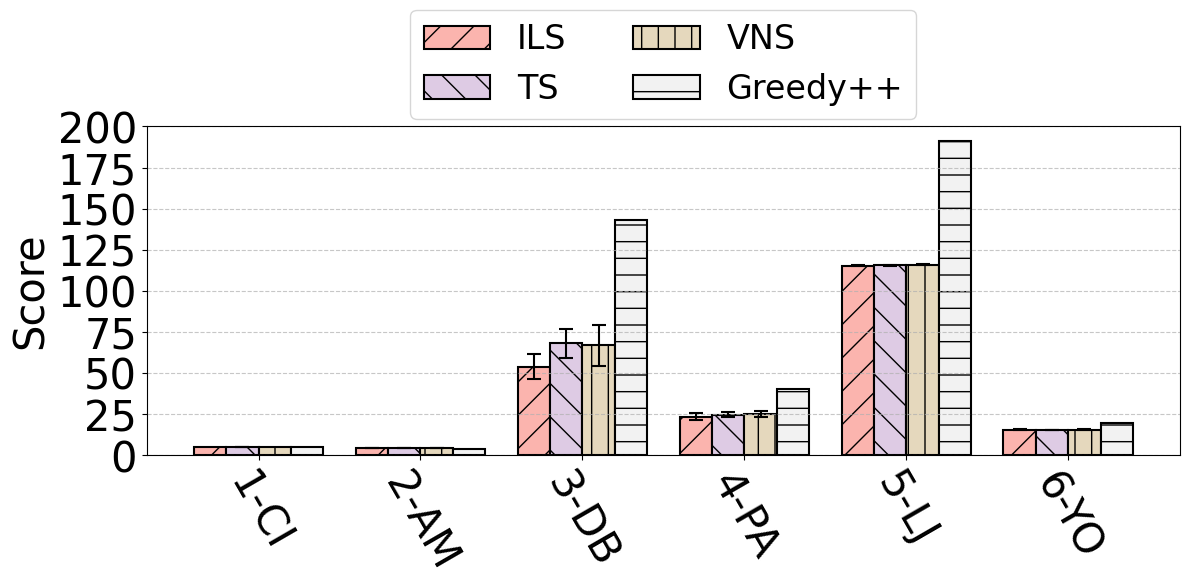

In [85]:
plot_optimality(grouped_df, "densesubgraph", 100)

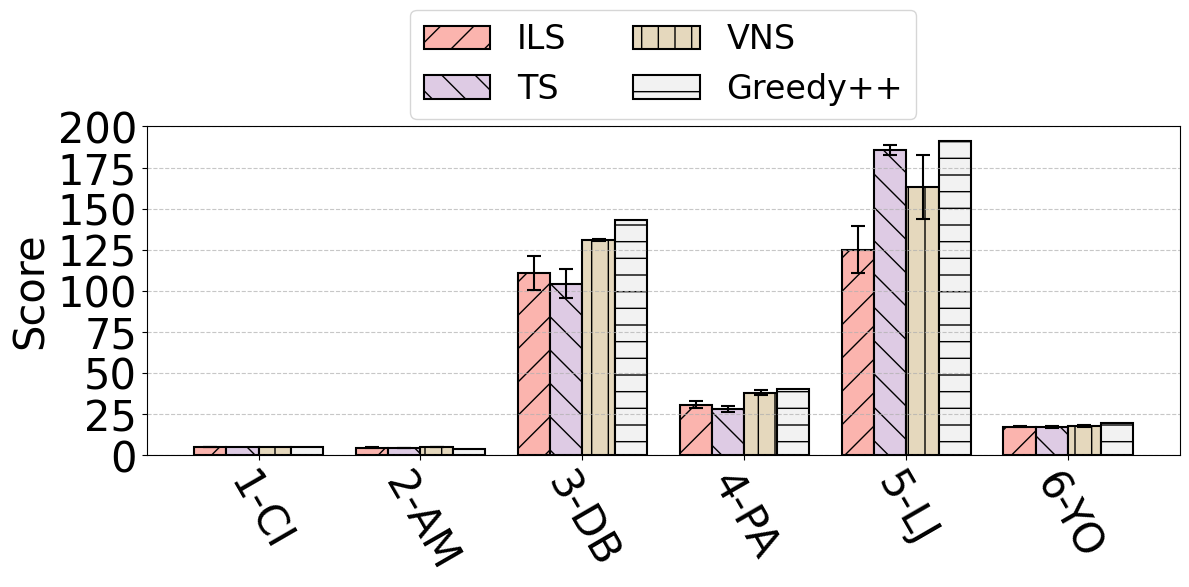

In [86]:
plot_optimality(grouped_df, "densesubgraph", 1000)

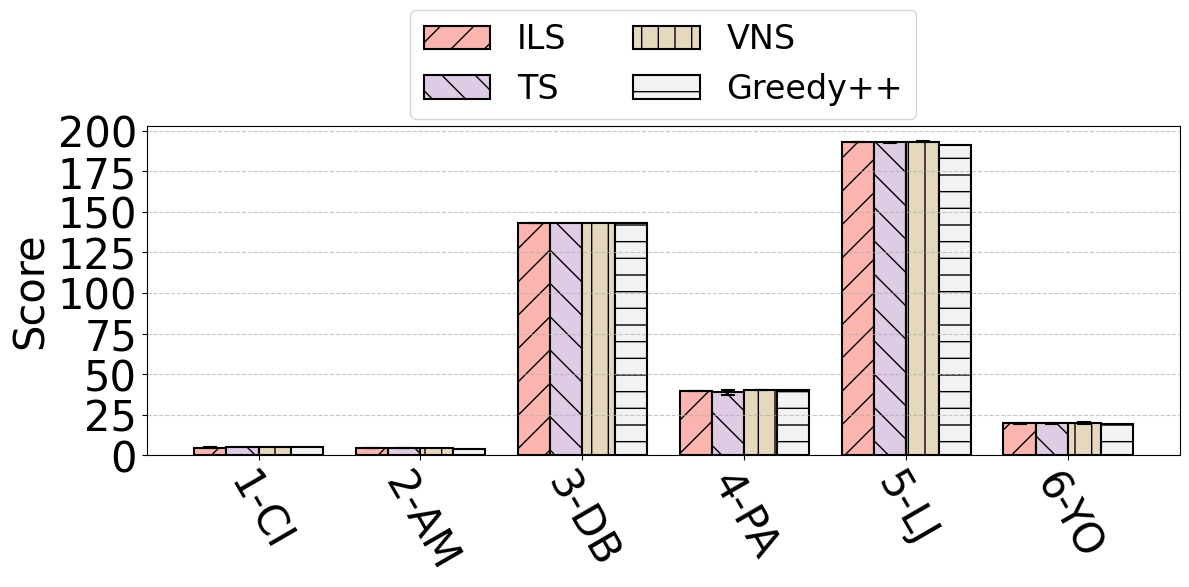

In [87]:
plot_optimality(grouped_df, "densesubgraph", 10000)

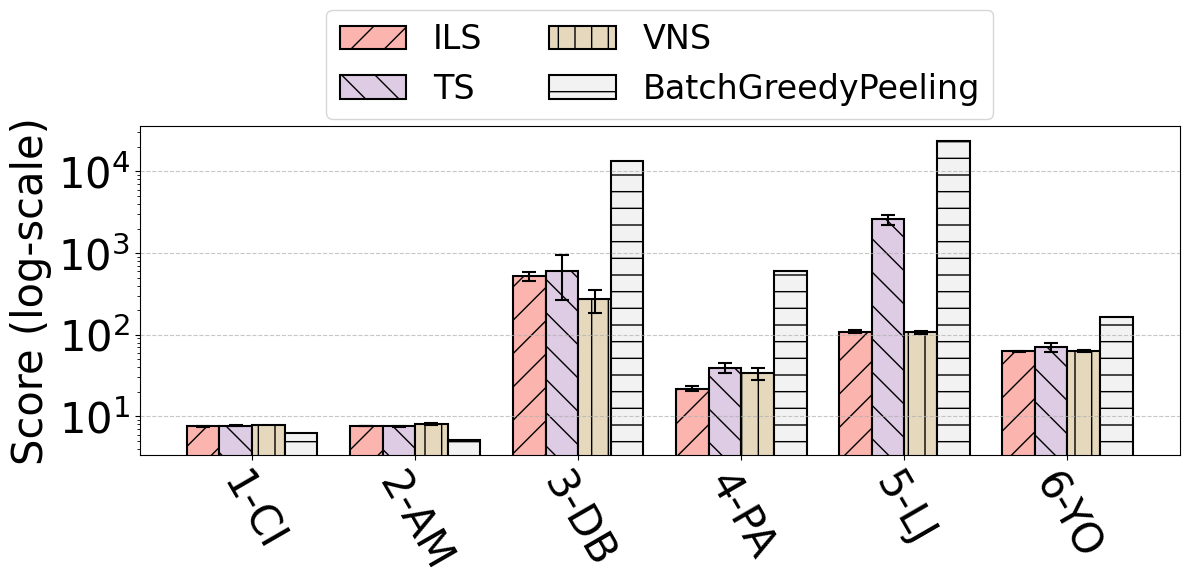

In [88]:
plot_optimality(grouped_df, "triangledensestsubgraph", 100)

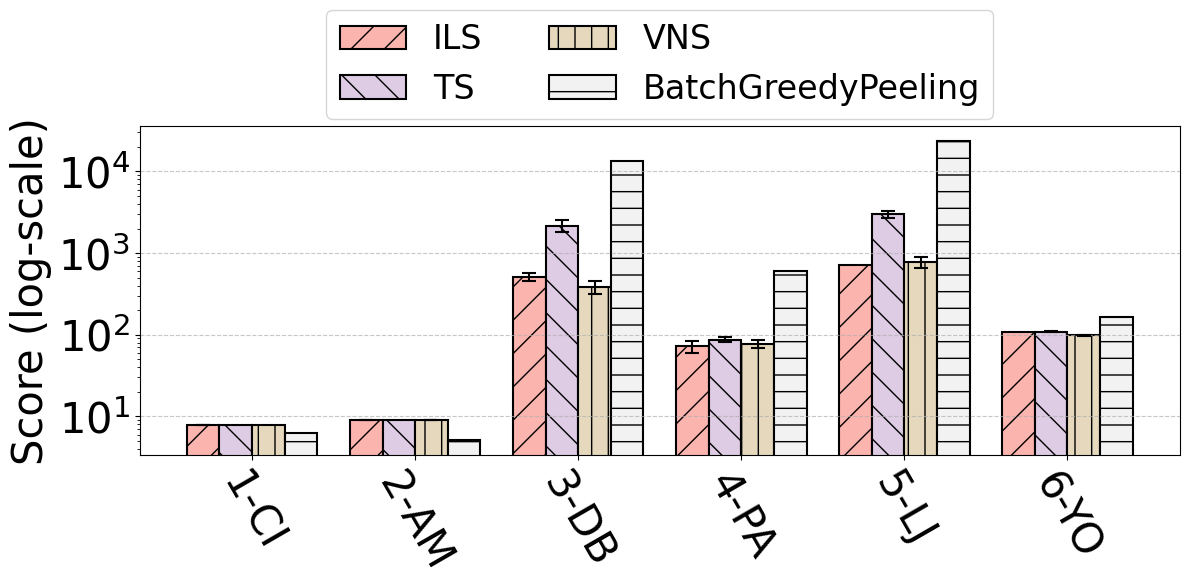

In [89]:
plot_optimality(grouped_df, "triangledensestsubgraph", 1000)

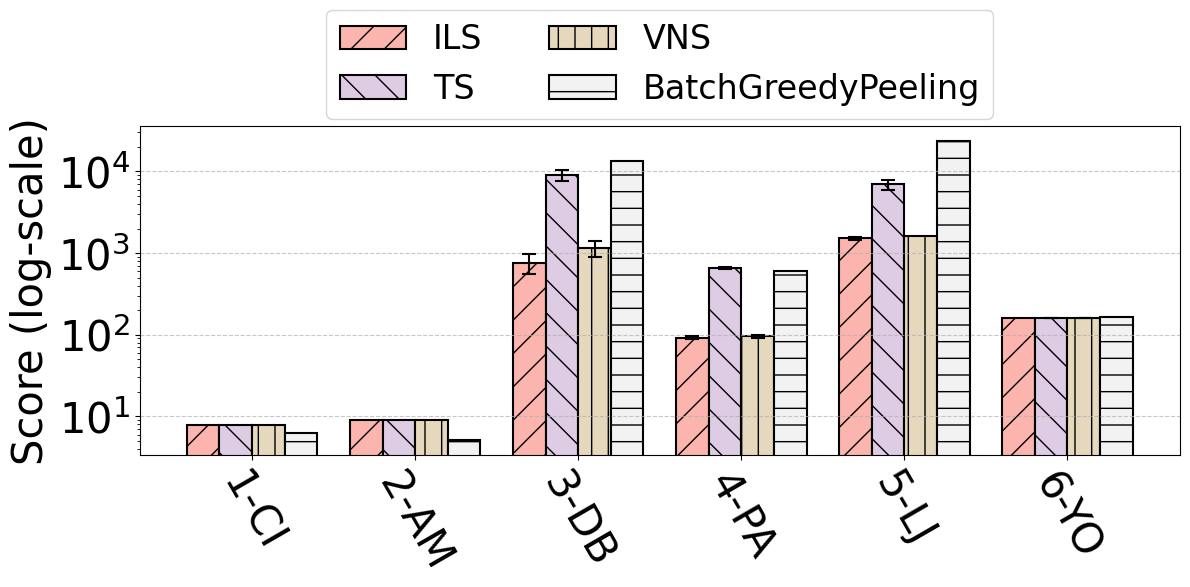

In [90]:
plot_optimality(grouped_df, "triangledensestsubgraph", 10000)

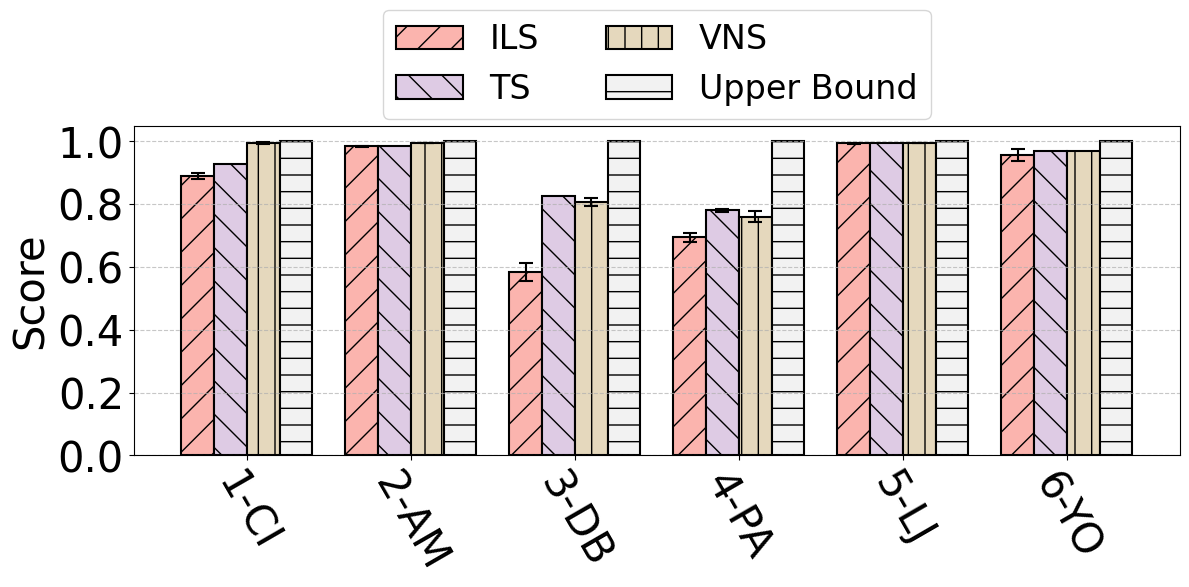

In [91]:
plot_optimality(grouped_df, "conductance", 100)

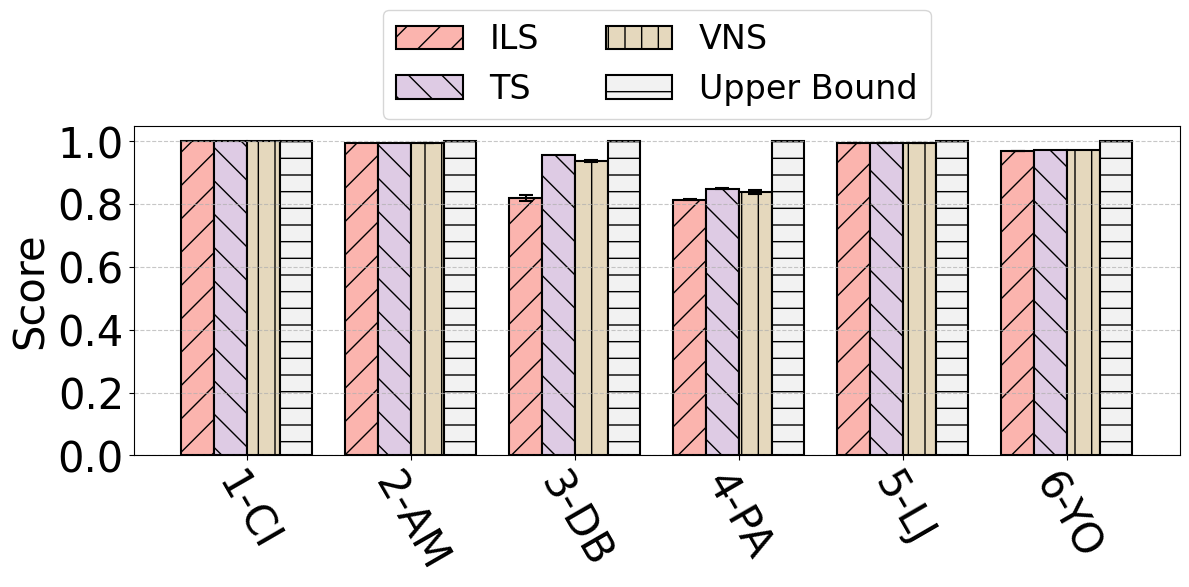

In [92]:
plot_optimality(grouped_df, "conductance", 1000)

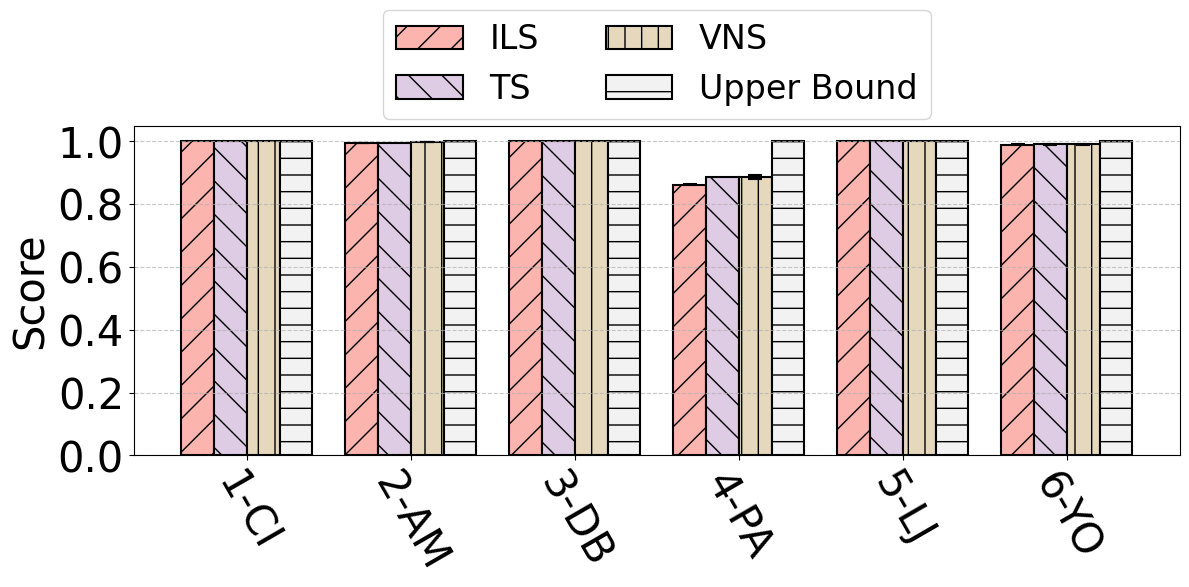

In [93]:
plot_optimality(grouped_df, "conductance", 10000)

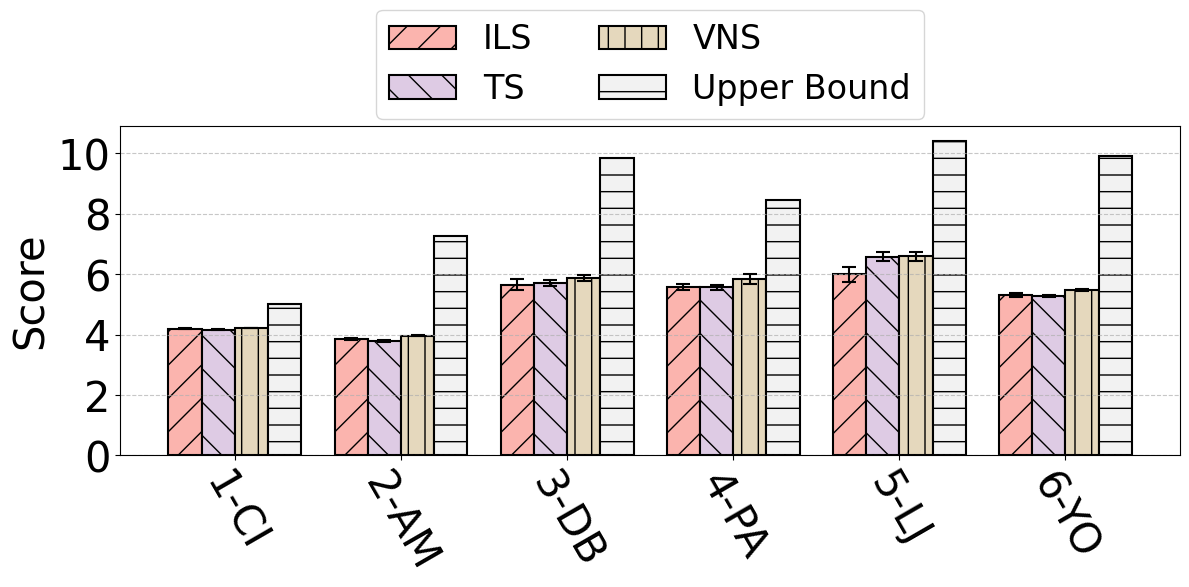

In [94]:
plot_optimality(grouped_df, "degreeentropy", 100)

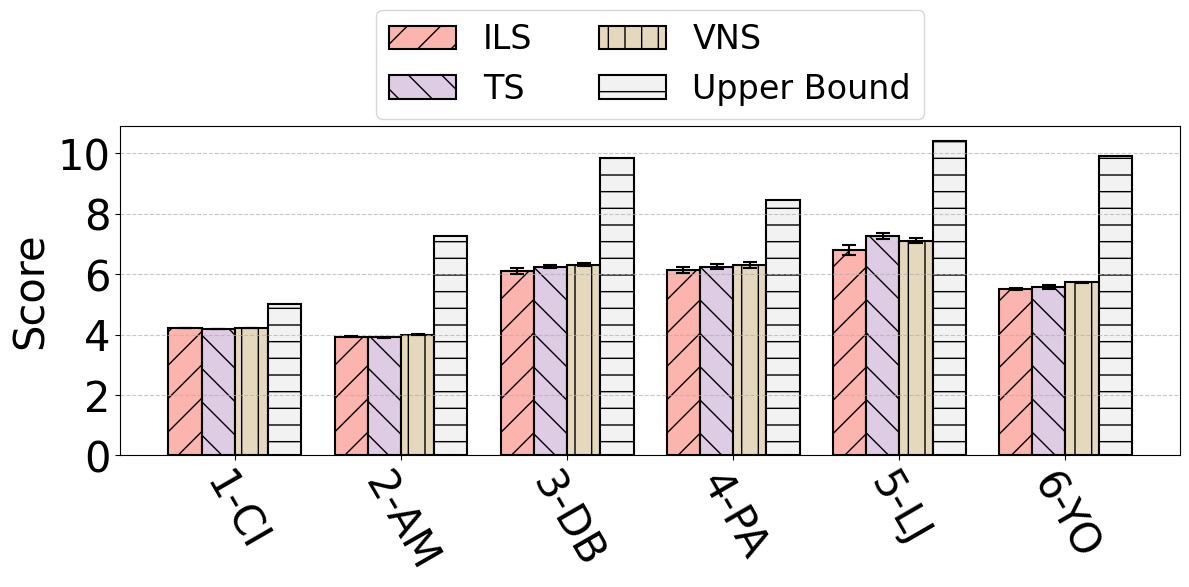

In [95]:
plot_optimality(grouped_df, "degreeentropy", 1000)

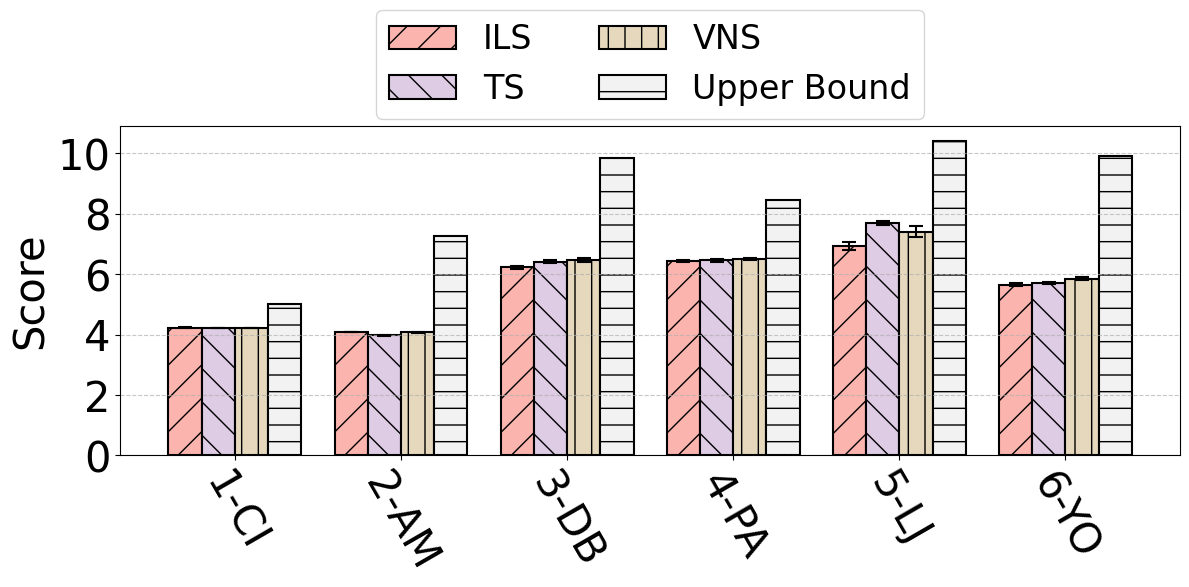

In [96]:
plot_optimality(grouped_df, "degreeentropy", 10000)

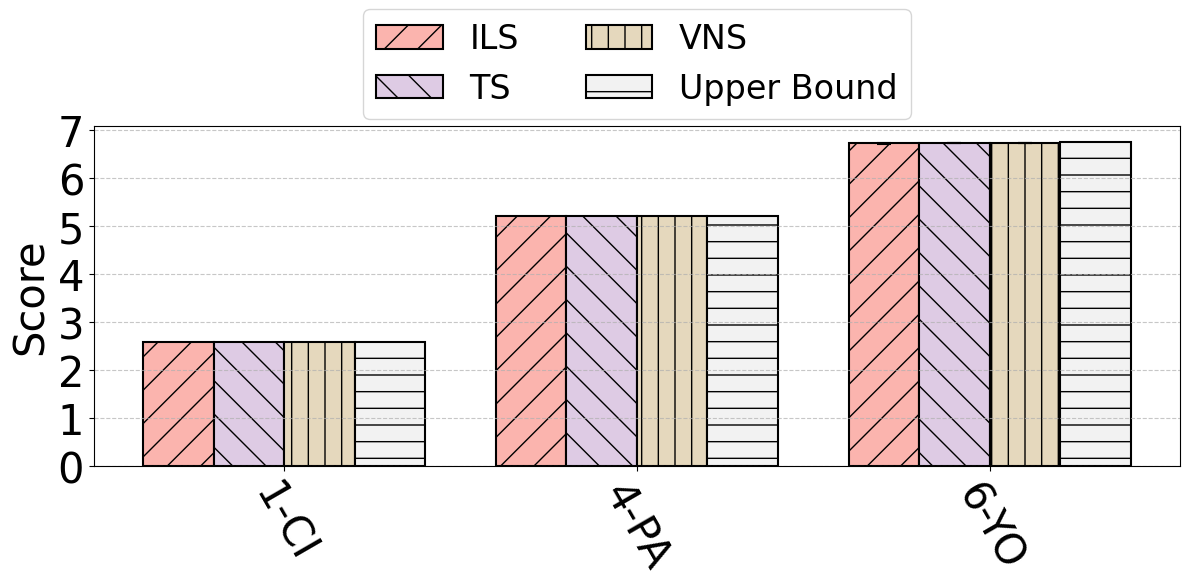

In [97]:
plot_optimality(grouped_df, "labelentropy", 100)

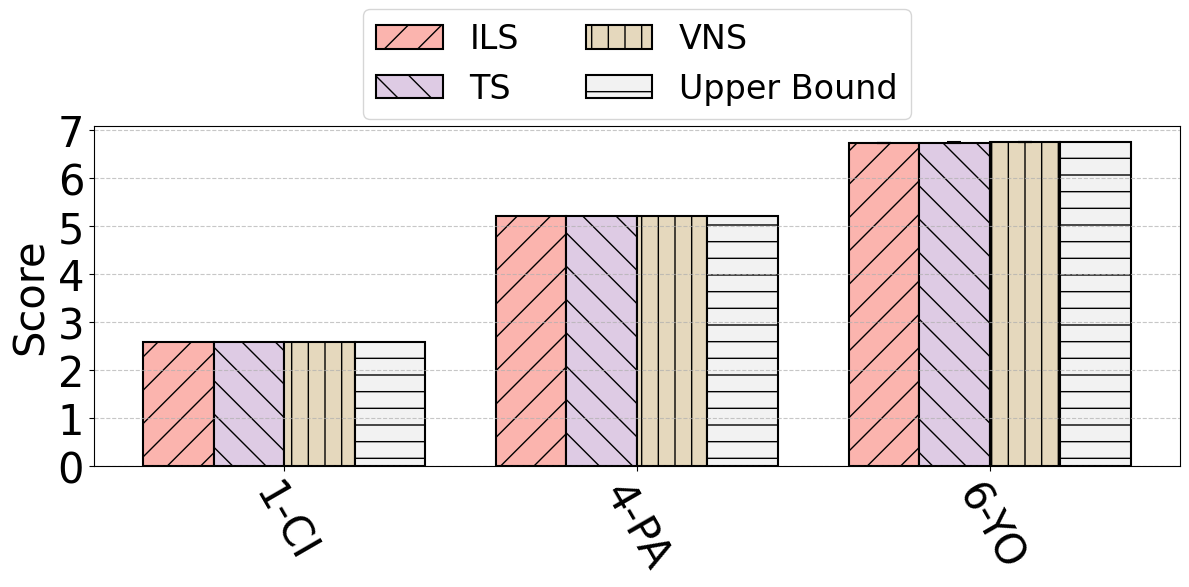

In [98]:
plot_optimality(grouped_df, "labelentropy", 1000)

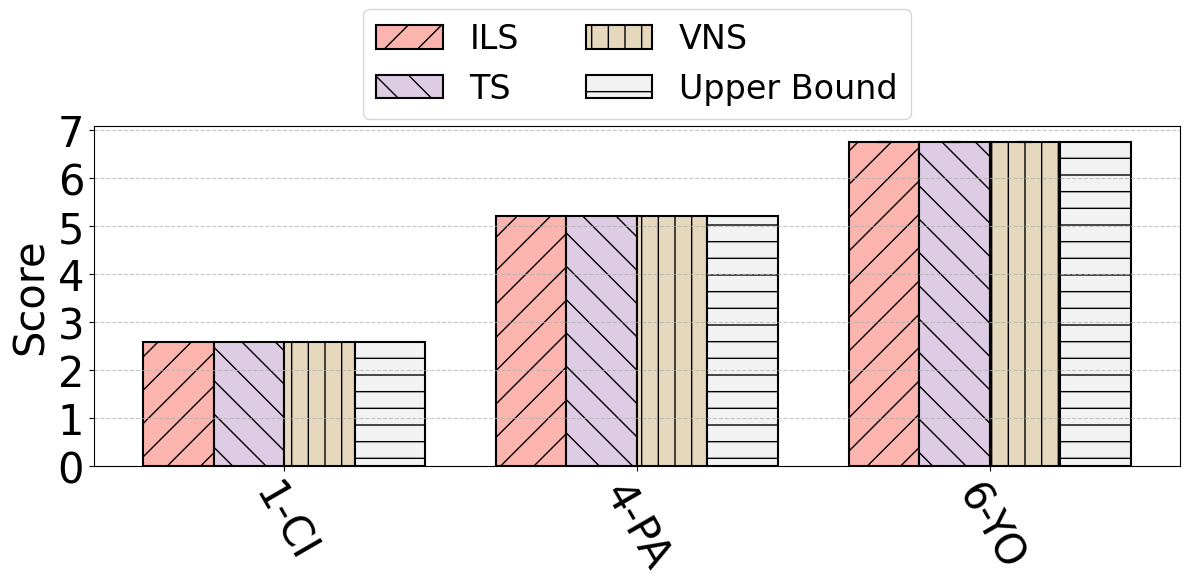

In [99]:
plot_optimality(grouped_df, "labelentropy", 10000)